# HIPPIE Cross-Dataset Analysis

This notebook replicates the Figure 6 CVAE generative analysis from the Nature Communications paper, adapted for any trained HIPPIE checkpoint and any pair (or set) of datasets.

**Panels reproduced:**
- **G0** — Latent-space linear probe (cell-type decodability)
- **G1** — Cross-modal imputation: mask one modality at encode time, measure reconstruction MSE
- **G2** — Cross-dataset counterfactual: encode cells from dataset A, decode under dataset B conditioning
- **Latent flow** — UMAP of multi-dataset embeddings coloured by cell type and source

All figures are saved to `figures/cross_dataset_analysis/`.

## 0. Configuration

In [12]:
from pathlib import Path

# ── Checkpoint ────────────────────────────────────────────────────────────────
# The Figure 6 checkpoint — trained jointly on Hull(0), Hausser(1), DANDI-000041(2),
# Lissberger(3).  z_dim=16, no class embedding (source-only conditioning).
CKPT_PATH = "../hippie_benchmarking/results/18_cvae_only_experiments/hippie_cvae.ckpt"

# ── Datasets ──────────────────────────────────────────────────────────────────
# source_id must match training order: Hull=0, Hausser=1, DANDI-000041=2, Lissberger=3
DATASETS = [
    ("Hull",       "datasets_hippie/hull_cell_type",               0),
    ("Hausser",    "datasets_hippie/hausser_cell_type",             1),
    ("Lissberger", "datasets_hippie/lissberger_labeled_cell_type",  3),
]

# G2: cross-species transfer — encode macaque (Lissberger), decode under mouse (Hausser)
# matches Figure 6A in the paper
G2_SOURCE_IDX = 2   # Lissberger (macaque)
G2_TARGET_IDX = 1   # Hausser    (mouse)

# ── Output ────────────────────────────────────────────────────────────────────
OUT_DIR = Path("figures/cross_dataset_analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cpu"   # change to "cuda" if GPU available
BATCH_SIZE = 256
RANDOM_SEED = 42

## 1. Imports & path setup

In [13]:
import sys, os
sys.path.insert(0, os.path.abspath("hippie"))   # bare imports inside the package

import numpy as np
import pandas as pd
import torch
import umap as umap_lib
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from dataclasses import dataclass, field
from typing import Iterable
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder

from multimodal_model import MultiModalCVAE, CVAEConfig
from dataloading import MultiModalEphysDataset, none_safe_collate

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
print(f"Imports OK  (umap {umap_lib.__version__})")

Imports OK  (umap 0.5.5)


## 2. Model & data utilities

Adapted from `hippie_benchmarking/analysis/CVAE_only_experiment_utils.py`.

In [14]:
@dataclass
class LoadedModel:
    model: torch.nn.Module
    modalities: dict        # {name: int output_size}
    num_sources: int
    num_classes: int | None
    num_super_regions: int | None
    z_dim: int


def _strip_prefix(sd):
    return {k[len("model."):] if k.startswith("model.") else k: v for k, v in sd.items()}


def _infer_modalities(sd):
    """Read modality → output_size from decoder linear_out weights."""
    mods = {}
    for key, tensor in sd.items():
        if key.startswith("decoders.") and key.endswith(".linear_out.weight"):
            name = key[len("decoders."):-len(".linear_out.weight")]
            mods[name] = int(tensor.shape[0])
    return mods


def _infer_dims(sd):
    src  = sd.get("source_embedding.weight")
    cls  = sd.get("class_embedding.weight")
    sr   = sd.get("super_region_embedding.weight")
    zmean= sd.get("z_mean.weight")
    if zmean is None:
        raise KeyError("z_mean.weight not found — not a HIPPIE checkpoint?")
    return (
        int(src.shape[0]) if src is not None else 0,
        int(cls.shape[0]) if cls is not None else None,
        int(sr.shape[0])  if sr  is not None else None,
        int(zmean.shape[0]),
    )


def load_hippie_checkpoint(ckpt_path: str, device: str = "cpu") -> LoadedModel:
    """Load a HIPPIE .ckpt, infer all dimensions from state_dict."""
    raw = torch.load(ckpt_path, map_location="cpu")
    sd  = _strip_prefix(raw.get("state_dict", raw))
    mods = _infer_modalities(sd)
    assert mods, "No decoder modalities found in checkpoint."
    num_sources, num_classes, num_sr, z_dim = _infer_dims(sd)

    cfg = CVAEConfig()
    cfg.use_source_embedding       = num_sources > 0
    cfg.use_class_embedding        = num_classes is not None
    cfg.use_super_region_embedding = num_sr      is not None
    cfg.encoder_uses_class_embedding = False   # production config — decoder only

    model = MultiModalCVAE(
        modalities=mods, z_dim=z_dim, config=cfg,
        num_sources=num_sources if num_sources > 0 else None,
        num_classes=num_classes, num_super_regions=num_sr,
    )
    missing, unexpected = model.load_state_dict(sd, strict=False)
    if missing:    print(f"  missing  keys: {len(missing)}  e.g. {missing[:2]}")
    if unexpected: print(f"  unexpected keys: {len(unexpected)}  e.g. {unexpected[:2]}")
    model = model.to(device).eval()
    print(f"Loaded checkpoint  z_dim={z_dim}  modalities={list(mods)}  "
          f"sources={num_sources}  classes={num_classes}  super_regions={num_sr}")
    return LoadedModel(model, mods, num_sources, num_classes, num_sr, z_dim)


_CSV_MAP = {"wave": "waveforms.csv", "isi": "isi_dist.csv", "acg": "acg.csv"}
_BAD_LABELS = {"unlabeled", "b''", "", "nan"}


def _clean_label(lbl: str) -> str:
    """Strip b'...' byte-string wrapper that pandas reads from some CSV files.
    e.g. "b'PkC_ss'" -> "PkC_ss", "b'unlabeled'" -> "unlabeled"
    """
    s = lbl.strip()
    if (s.startswith("b'") and s.endswith("'")) or (s.startswith('b"') and s.endswith('"')):
        return s[2:-1]
    return s


def load_dataset(data_dir, modalities, target_sizes=None):
    """Return dict with modality arrays + labels.
    Rows with unlabeled / b'' / empty labels are dropped.
    b'...' byte-string wrappers are stripped from label values."""
    data_dir = Path(data_dir)
    out = {}
    for mod in modalities:
        csv = data_dir / _CSV_MAP.get(mod, f"{mod}.csv")
        arr = pd.read_csv(csv).to_numpy().astype(np.float32)
        arr = np.nan_to_num(arr)
        if target_sizes and mod in target_sizes and arr.shape[1] != target_sizes[mod]:
            src = np.linspace(0, 1, arr.shape[1])
            dst = np.linspace(0, 1, target_sizes[mod])
            arr = np.stack([np.interp(dst, src, row) for row in arr]).astype(np.float32)
        out[mod] = arr

    for fname in ("labels.csv", "celltypes.csv"):
        p = data_dir / fname
        if p.exists():
            df = pd.read_csv(p)
            raw_labels = df[df.columns[0]].astype(str).values
            break
    else:
        n = len(next(iter(out.values())))
        raw_labels = np.array(["unlabeled"] * n)

    # Strip b'...' wrapper then filter bad labels
    clean_labels = np.array([_clean_label(l) for l in raw_labels])
    keep = np.array([l.strip().lower() not in _BAD_LABELS for l in clean_labels])
    n_dropped = (~keep).sum()
    if n_dropped:
        print(f"    [{Path(data_dir).name}] dropping {n_dropped} unlabeled/empty rows")
    out = {m: v[keep] for m, v in out.items()}
    out["labels"] = clean_labels[keep]

    if (data_dir / "source_id.csv").exists():
        src_arr = pd.read_csv(data_dir / "source_id.csv").to_numpy().ravel().astype(np.int64)
        out["source_id"] = src_arr[keep]
    return out


def make_loader(data, modalities, batch_size=256, indices=None):
    mods = list(modalities)
    if indices is not None:
        subset = {m: data[m][indices] for m in mods}
    else:
        subset = {m: data[m] for m in mods}
    n = len(subset[mods[0]])
    ds = MultiModalEphysDataset(subset, np.arange(n), mode="multi", normalize=True)
    return DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=none_safe_collate)


@torch.no_grad()
def encode_all(lm: LoadedModel, data: dict, source_id: int | None = None,
               mask_class: bool = True) -> np.ndarray:
    """Return (N, z_dim) array of encoder means μ.
    encode() returns (h, z_mean, z_log_var); we take z_mean."""
    device = next(lm.model.parameters()).device
    mods   = list(lm.modalities.keys())
    src_labels = (
        torch.full((BATCH_SIZE,), source_id, dtype=torch.long, device=device)
        if source_id is not None else None
    )
    mus = []
    loader = make_loader(data, mods)
    for batch in loader:
        if batch is None: continue
        batch_data, _ = batch
        b = len(next(iter(batch_data.values())))
        batch_data = {k: v.to(device) for k, v in batch_data.items()}
        sl = src_labels[:b] if src_labels is not None else None
        _, mu, _ = lm.model.encode(batch_data, source_labels=sl, class_labels=None)
        mus.append(mu.cpu().numpy())
    return np.vstack(mus)


@torch.no_grad()
def decode_z(lm: LoadedModel, z: np.ndarray, source_id: int | None = None,
             class_id: int | None = None) -> dict:
    """Decode a single z vector (or batch). Returns {modality: np.ndarray}."""
    device = next(lm.model.parameters()).device
    if z.ndim == 1:
        z = z[None]
    z_t = torch.tensor(z, dtype=torch.float32, device=device)
    n = len(z_t)
    sl = torch.full((n,), source_id, dtype=torch.long, device=device) if source_id is not None else None
    cl = torch.full((n,), class_id,  dtype=torch.long, device=device) if class_id  is not None else None
    out = lm.model.decode(z_t, source_labels=sl, class_labels=cl)
    return {k: v.cpu().numpy() for k, v in out.items()}


print("Utilities defined.")

Utilities defined.


## 3. Load model & datasets

In [15]:
lm = load_hippie_checkpoint(CKPT_PATH, device=DEVICE)

datasets = {}
for name, path, src_id in DATASETS:
    d = load_dataset(path, lm.modalities, target_sizes=lm.modalities)
    d["_source_id"] = src_id
    d["_name"]      = name
    n = len(d["labels"])
    print(f"  {name:20s}  n={n:5d}  classes={sorted(set(d['labels']))}")
    datasets[name] = d

MODALITIES = list(lm.modalities.keys())
print(f"\nModalities: {MODALITIES}  z_dim={lm.z_dim}")

Loaded checkpoint  z_dim=16  modalities=['wave', 'isi', 'acg']  sources=4  classes=None  super_regions=2
  Hull                  n=  206  classes=['GoC', 'MFB', 'MLI', 'PkC_cs', 'PkC_ss']
    [hausser_cell_type] dropping 3770 unlabeled/empty rows
  Hausser               n=  226  classes=['GoC', 'MFB', 'MLI', 'PkC_cs', 'PkC_ss']
    [lissberger_labeled_cell_type] dropping 484 unlabeled/empty rows
  Lissberger            n=  668  classes=['GoC', 'MFB', 'MLI', 'PkC_cs', 'PkC_ss']

Modalities: ['wave', 'isi', 'acg']  z_dim=16


## 4. Encode all datasets → latent space

In [16]:
embeddings = {}
for name, d in datasets.items():
    Z = encode_all(lm, d, source_id=d["_source_id"])
    embeddings[name] = Z
    print(f"  {name:20s}  Z.shape={Z.shape}")

  Hull                  Z.shape=(206, 16)
  Hausser               Z.shape=(226, 16)
  Lissberger            Z.shape=(668, 16)


## 5. UMAP — multi-dataset latent space

Two views: coloured by **cell type** and by **source dataset**.

/Users/jesusgf/opt/miniconda3/envs/electro_phys/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jesusgf/opt/miniconda3/envs/electro_phys/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP done  shape=(1100, 2)
Saved → figures/cross_dataset_analysis/umap_combined.pdf


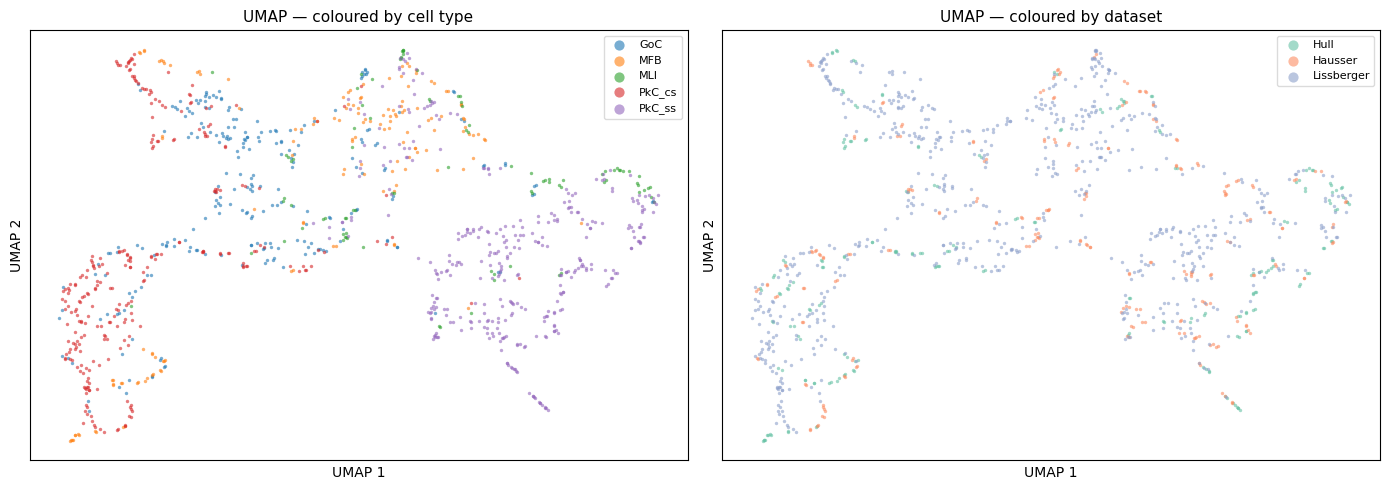

In [17]:
Z_all    = np.vstack([embeddings[n] for n in datasets])
labs_all = np.concatenate([datasets[n]["labels"] for n in datasets])
src_all  = np.concatenate([[n] * len(datasets[n]["labels"]) for n in datasets])

reducer = umap_lib.UMAP(n_neighbors=15, min_dist=0.3, random_state=RANDOM_SEED)
Z2 = reducer.fit_transform(Z_all)
print(f"UMAP done  shape={Z2.shape}")

# ── Colour maps ───────────────────────────────────────────────────────────────
all_cts    = sorted(set(labs_all))
all_srcs   = list(datasets.keys())
ct_colors  = {ct: c for ct, c in zip(all_cts,  plt.cm.tab10.colors)}
src_colors = {s:  c for s,  c in zip(all_srcs, plt.cm.Set2.colors)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: cell type
ax = axes[0]
for ct in all_cts:
    mask = labs_all == ct
    ax.scatter(Z2[mask, 0], Z2[mask, 1], s=6, alpha=0.6,
               color=ct_colors[ct], label=ct, linewidths=0)
ax.set_title("UMAP — coloured by cell type", fontsize=11)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.legend(markerscale=3, fontsize=8, loc="best", framealpha=0.7)
ax.set_xticks([]); ax.set_yticks([])

# Panel 2: dataset source
ax = axes[1]
for src in all_srcs:
    mask = src_all == src
    ax.scatter(Z2[mask, 0], Z2[mask, 1], s=6, alpha=0.6,
               color=src_colors[src], label=src, linewidths=0)
ax.set_title("UMAP — coloured by dataset", fontsize=11)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.legend(markerscale=3, fontsize=8, loc="best", framealpha=0.7)
ax.set_xticks([]); ax.set_yticks([])

fig.tight_layout()
out_path = OUT_DIR / "umap_combined.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

## 6. G0 — Linear probe (cell-type decodability)

Stratified k-fold LogisticRegression on μ vectors. Mirrors Figure 6C.

  Hull                  bal_acc=0.899 ± 0.026  macro_F1=0.805
  Hausser               bal_acc=0.622 ± 0.096  macro_F1=0.591
  Lissberger            bal_acc=0.743 ± 0.039  macro_F1=0.720
Saved → figures/cross_dataset_analysis/G0_linear_probe.pdf


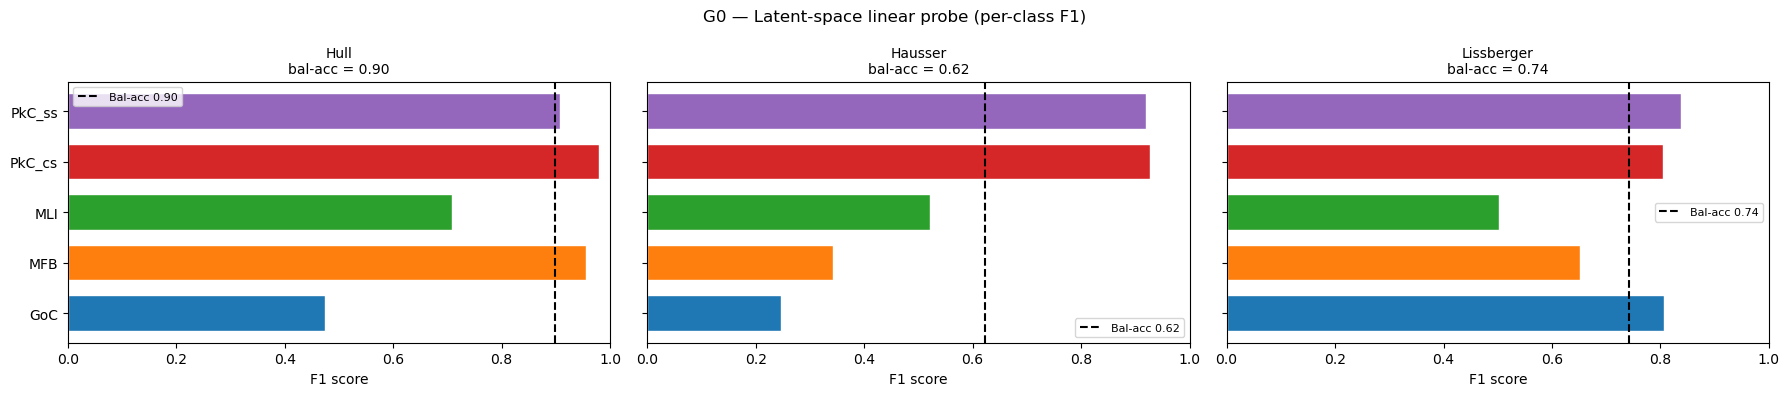

In [18]:
def cv_classify(Z, y, n_splits=5):
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    classes = le.classes_
    if len(classes) < 2:
        return {"balanced_accuracy": np.nan, "macro_f1": np.nan,
                "per_class_f1": {}, "classes": classes}
    k = min(n_splits, int(np.bincount(y_enc).min()))
    k = max(k, 2)
    bas, f1s, per_class = [], [], {}
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_SEED)
    for tr, te in skf.split(Z, y_enc):
        clf = LogisticRegression(max_iter=500, class_weight="balanced", C=1.0)
        clf.fit(Z[tr], y_enc[tr])
        pred = clf.predict(Z[te])
        bas.append(balanced_accuracy_score(y_enc[te], pred))
        f1s.append(f1_score(y_enc[te], pred, average="macro", zero_division=0))
        for i, ct in enumerate(classes):
            per_class.setdefault(ct, []).append(
                f1_score(y_enc[te] == i, pred == i, zero_division=0))
    return {
        "balanced_accuracy": float(np.mean(bas)),
        "balanced_accuracy_std": float(np.std(bas)),
        "macro_f1": float(np.mean(f1s)),
        "per_class_f1": {ct: float(np.mean(v)) for ct, v in per_class.items()},
        "classes": classes,
    }


g0_results = {}
for name in datasets:
    Z = embeddings[name]
    y = datasets[name]["labels"]
    res = cv_classify(Z, y)
    g0_results[name] = res
    print(f"  {name:20s}  bal_acc={res['balanced_accuracy']:.3f} ± {res['balanced_accuracy_std']:.3f}  "
          f"macro_F1={res['macro_f1']:.3f}")

# ── Per-class F1 bar chart ─────────────────────────────────────────────────
n_ds = len(g0_results)
fig, axes = plt.subplots(1, n_ds, figsize=(6 * n_ds, 4), sharey=True)
if n_ds == 1: axes = [axes]

for ax, (name, res) in zip(axes, g0_results.items()):
    cts = list(res["per_class_f1"].keys())
    f1s = [res["per_class_f1"][ct] for ct in cts]
    colors = [ct_colors.get(ct, "steelblue") for ct in cts]
    ax.barh(cts, f1s, color=colors, edgecolor="white", height=0.7)
    ax.axvline(res["balanced_accuracy"], color="k", lw=1.5, ls="--",
               label=f'Bal-acc {res["balanced_accuracy"]:.2f}')
    ax.set_xlim(0, 1)
    ax.set_xlabel("F1 score")
    ax.set_title(f"{name}\nbal-acc = {res['balanced_accuracy']:.2f}", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("G0 — Latent-space linear probe (per-class F1)", fontsize=12)
fig.tight_layout()
out_path = OUT_DIR / "G0_linear_probe.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

## 7. G1 — Cross-modal imputation

For each modality, zero it out at encode time and measure the reconstruction MSE
of all modalities.  Mirrors Figure 6B heatmap.

  Hull
        recon_wave_mse  recon_isi_mse  recon_acg_mse
masked                                              
wave          0.424167       0.262876            NaN
isi           0.178964       0.308549            NaN
acg           0.182056       0.299811            NaN
  Hausser
        recon_wave_mse  recon_isi_mse  recon_acg_mse
masked                                              
wave          0.414227       0.224072            NaN
isi           0.213525       0.295861            NaN
acg           0.215160       0.295776            NaN
  Lissberger
        recon_wave_mse  recon_isi_mse  recon_acg_mse
masked                                              
wave          0.394272       0.312531            NaN
isi           0.155990       0.401129            NaN
acg           0.158502       0.350899            NaN
Saved → figures/cross_dataset_analysis/G1_cross_modal_imputation.pdf


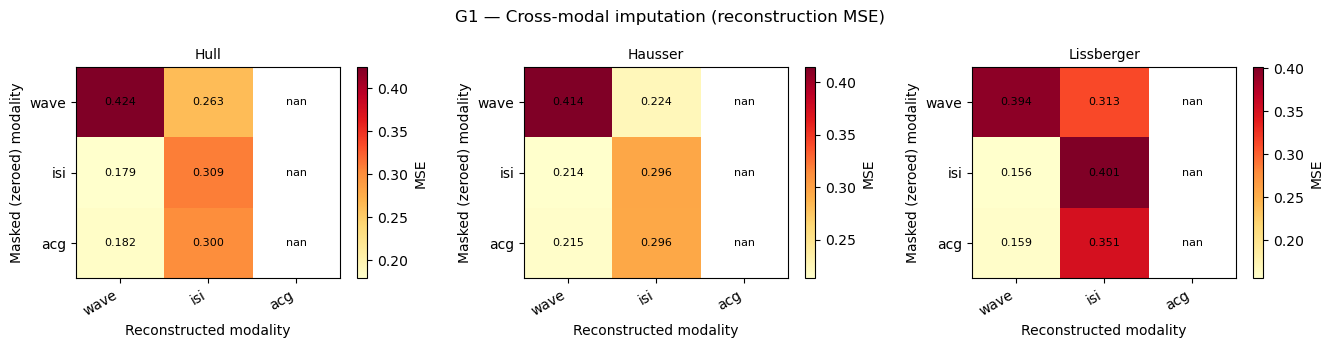

In [19]:
@torch.no_grad()
def cross_modal_imputation(lm, data, source_id):
    """Returns DataFrame: rows=masked_modality, cols=reconstructed_modality, values=MSE."""
    device = next(lm.model.parameters()).device
    mods   = list(lm.modalities.keys())
    loader = make_loader(data, mods, batch_size=BATCH_SIZE)
    sl_full = torch.full((BATCH_SIZE,), source_id, dtype=torch.long, device=device)

    rows = []
    for masked_mod in mods:
        sq_err = {m: 0.0 for m in mods}
        counts = {m: 0   for m in mods}
        for batch in loader:
            if batch is None: continue
            bd, _ = batch
            b = len(next(iter(bd.values())))
            bd = {k: v.to(device) for k, v in bd.items()}
            sl = sl_full[:b]

            # Mask one modality
            bd_masked = {k: (torch.zeros_like(v) if k == masked_mod else v)
                         for k, v in bd.items()}
            # encode() returns (h, z_mean, z_log_var); use z_mean
            _, mu, _ = lm.model.encode(bd_masked, source_labels=sl, class_labels=None)
            decoded = lm.model.decode(mu, source_labels=sl, class_labels=None)

            for m in mods:
                sq_err[m] += ((decoded[m] - bd[m]) ** 2).sum().item()
                counts[m] += bd[m].numel()

        rows.append({"masked": masked_mod,
                     **{f"recon_{m}_mse": sq_err[m] / counts[m] for m in mods}})

    return pd.DataFrame(rows).set_index("masked")


g1_results = {}
for name, d in datasets.items():
    g1_results[name] = cross_modal_imputation(lm, d, source_id=d["_source_id"])
    print(f"  {name}")
    print(g1_results[name].to_string())

# ── Heatmap ───────────────────────────────────────────────────────────────────
n_ds = len(g1_results)
fig, axes = plt.subplots(1, n_ds, figsize=(4.5 * n_ds, 3.5))
if n_ds == 1: axes = [axes]

for ax, (name, df) in zip(axes, g1_results.items()):
    mat = df.rename(columns=lambda c: c.replace("recon_", "").replace("_mse", ""))
    im  = ax.imshow(mat.values, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(mat.index)));   ax.set_yticklabels(mat.index)
    ax.set_xlabel("Reconstructed modality")
    ax.set_ylabel("Masked (zeroed) modality")
    ax.set_title(name, fontsize=10)
    plt.colorbar(im, ax=ax, label="MSE")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat.values[i,j]:.3f}", ha="center", va="center",
                    fontsize=8, color="white" if mat.values[i,j] > mat.values.max()*0.6 else "black")

fig.suptitle("G1 — Cross-modal imputation (reconstruction MSE)", fontsize=12)
fig.tight_layout()
out_path = OUT_DIR / "G1_cross_modal_imputation.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

## 8. G2 — Cross-dataset counterfactual

Encode cells from dataset A, then decode under dataset B's source conditioning.
For each shared cell type, compare the counterfactual prediction to the real
population mean in dataset B.  Mirrors Figure 6A cross-species panel.

Shared cell types (Lissberger ↔ Hausser): ['GoC', 'MFB', 'MLI', 'PkC_cs', 'PkC_ss']
cell_type modality  n_src  n_tgt  counterfactual_vs_target_mse
      GoC     wave    188     50                  3.628321e+01
      GoC      isi    188     50                  1.778290e+05
      GoC      acg    188     50                           NaN
      MFB     wave     86     26                  3.288904e+01
      MFB      isi     86     26                  2.525158e+05
      MFB      acg     86     26                           NaN
      MLI     wave     36     30                  1.369883e+01
      MLI      isi     36     30                  2.620477e+05
      MLI      acg     36     30                           NaN
   PkC_cs     wave    147     50                  3.165724e+02
   PkC_cs      isi    147     50                  1.760458e+03
   PkC_cs      acg    147     50                           NaN
   PkC_ss     wave    211     70                  4.164651e+02
   PkC_ss      isi    211     70  

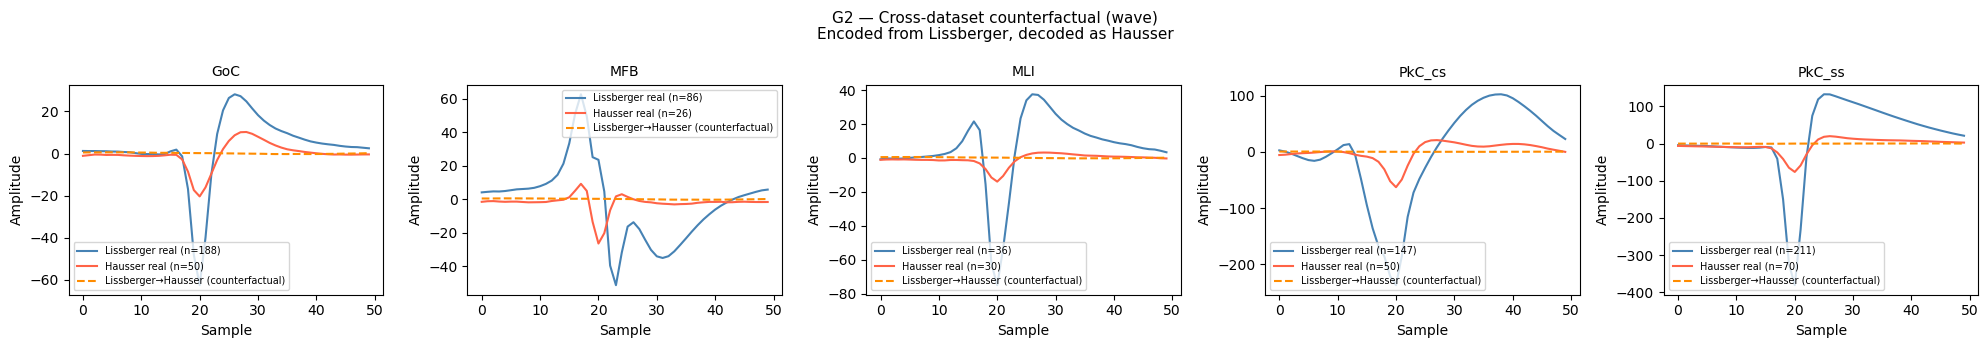

In [20]:
src_name  = list(datasets.keys())[G2_SOURCE_IDX]
tgt_name  = list(datasets.keys())[G2_TARGET_IDX]
d_src     = datasets[src_name]
d_tgt     = datasets[tgt_name]
src_id    = d_src["_source_id"]
tgt_id    = d_tgt["_source_id"]

shared_cts = sorted(set(d_src["labels"]) & set(d_tgt["labels"]))
print(f"Shared cell types ({src_name} ↔ {tgt_name}): {shared_cts}")

g2_rows = []
for ct in shared_cts:
    # Encode source cells of this type
    idx_src = np.where(d_src["labels"] == ct)[0]
    Z_src = encode_all(lm, {m: d_src[m][idx_src] for m in MODALITIES},
                       source_id=src_id)
    mean_z = Z_src.mean(axis=0, keepdims=True)

    # Decode under source conditioning (reconstruction)
    recon_src  = decode_z(lm, mean_z, source_id=src_id)
    # Decode under target conditioning (counterfactual)
    counter_tgt = decode_z(lm, mean_z, source_id=tgt_id)

    # Real target population mean
    idx_tgt = np.where(d_tgt["labels"] == ct)[0]

    for mod in MODALITIES:
        real_src_mean = d_src[mod][idx_src].mean(axis=0)
        real_tgt_mean = d_tgt[mod][idx_tgt].mean(axis=0) if len(idx_tgt) > 0 else None
        pred_mean     = counter_tgt[mod].squeeze()

        mse = float(((pred_mean - real_tgt_mean) ** 2).mean()) if real_tgt_mean is not None else np.nan
        g2_rows.append({"cell_type": ct, "modality": mod,
                         "n_src": len(idx_src), "n_tgt": len(idx_tgt) if len(idx_tgt) > 0 else 0,
                         "counterfactual_vs_target_mse": mse})

g2_df = pd.DataFrame(g2_rows)
print(g2_df.to_string(index=False))
g2_df.to_csv(OUT_DIR / "G2_cross_dataset_mse.csv", index=False)

# ── Waveform overlay plot ──────────────────────────────────────────────────────
mod_to_plot = MODALITIES[0]   # waveforms by default
n_ct = len(shared_cts)
fig, axes = plt.subplots(1, n_ct, figsize=(4 * n_ct, 3.5), sharey=False)
if n_ct == 1: axes = [axes]

for ax, ct in zip(axes, shared_cts):
    idx_src = np.where(d_src["labels"] == ct)[0]
    idx_tgt = np.where(d_tgt["labels"] == ct)[0]
    Z_src   = encode_all(lm, {m: d_src[m][idx_src] for m in MODALITIES}, source_id=src_id)
    mean_z  = Z_src.mean(axis=0, keepdims=True)
    counter = decode_z(lm, mean_z, source_id=tgt_id)[mod_to_plot].squeeze()

    x = np.arange(len(counter))
    ax.plot(x, d_src[mod_to_plot][idx_src].mean(0), color="steelblue",  lw=1.5,
            label=f"{src_name} real (n={len(idx_src)})")
    if len(idx_tgt) > 0:
        ax.plot(x, d_tgt[mod_to_plot][idx_tgt].mean(0), color="tomato",     lw=1.5,
                label=f"{tgt_name} real (n={len(idx_tgt)})")
    ax.plot(x, counter,                                  color="darkorange", lw=1.5, ls="--",
            label=f"{src_name}→{tgt_name} (counterfactual)")
    ax.set_title(ct, fontsize=10)
    ax.set_xlabel("Sample"); ax.set_ylabel("Amplitude")
    ax.legend(fontsize=7)

fig.suptitle(f"G2 — Cross-dataset counterfactual ({mod_to_plot})\n"
             f"Encoded from {src_name}, decoded as {tgt_name}", fontsize=11)
fig.tight_layout()
out_path = OUT_DIR / f"G2_counterfactual_{mod_to_plot}.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

## 9. Latent-space flow — waveform interpolation

Pick one shared cell type, pick a source and target cell, interpolate linearly
in 16-D latent space, decode at each step, and overlay the waveform traces.
Mirrors Figure 6D waterfall.

Saved → figures/cross_dataset_analysis/latent_flow_GoC.pdf


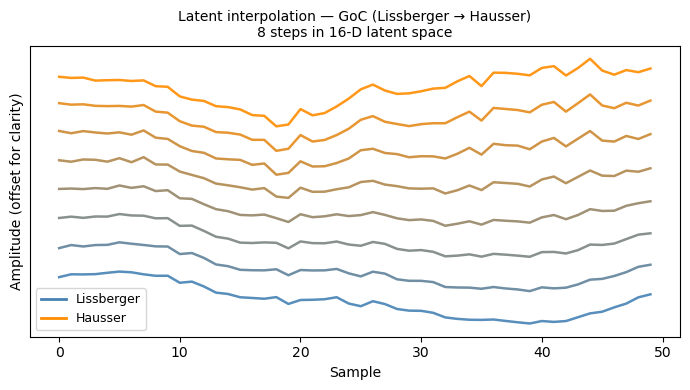

In [21]:
N_STEPS  = 8
FOCUS_CT = shared_cts[0] if shared_cts else list(set(datasets[list(datasets.keys())[0]]["labels"]))[0]

# Encode focus cells from both datasets
d_a = datasets[src_name]
d_b = datasets[tgt_name]
idx_a = np.where(d_a["labels"] == FOCUS_CT)[0]
idx_b = np.where(d_b["labels"] == FOCUS_CT)[0]

if len(idx_a) == 0 or len(idx_b) == 0:
    print(f"Cell type '{FOCUS_CT}' not present in both datasets — skip interpolation.")
else:
    Z_a = encode_all(lm, {m: d_a[m][idx_a] for m in MODALITIES}, source_id=src_id)
    Z_b = encode_all(lm, {m: d_b[m][idx_b] for m in MODALITIES}, source_id=tgt_id)
    z_start = Z_a.mean(axis=0)
    z_end   = Z_b.mean(axis=0)

    steps   = []
    ts      = np.linspace(0, 1, N_STEPS)
    for t in ts:
        z_interp = (1 - t) * z_start + t * z_end
        dec = decode_z(lm, z_interp[None], source_id=src_id)
        steps.append(dec[MODALITIES[0]].squeeze())

    # Colour-blend: blue → orange
    def blend(t): return tuple(np.array(mcolors.to_rgb("steelblue")) * (1-t) +
                                np.array(mcolors.to_rgb("darkorange")) * t)

    fig, ax = plt.subplots(figsize=(7, 4))
    x = np.arange(len(steps[0]))
    for i, (wave, t) in enumerate(zip(steps, ts)):
        offset = i * 0.3
        ax.plot(x, wave + offset, color=blend(t), lw=1.8, alpha=0.9)
    ax.set_xlabel("Sample"); ax.set_ylabel("Amplitude (offset for clarity)")
    ax.set_title(f"Latent interpolation — {FOCUS_CT} ({src_name} → {tgt_name})\n"
                 f"{N_STEPS} steps in {lm.z_dim}-D latent space", fontsize=10)
    handles = [Line2D([0],[0], color=blend(0), lw=2, label=src_name),
               Line2D([0],[0], color=blend(1), lw=2, label=tgt_name)]
    ax.legend(handles=handles, fontsize=9)
    ax.set_yticks([])
    fig.tight_layout()
    out_path = OUT_DIR / f"latent_flow_{FOCUS_CT}.pdf"
    fig.savefig(out_path, bbox_inches="tight")
    print(f"Saved → {out_path}")
    plt.show()

## 10. Summary table

In [22]:
summary = []
for name, res in g0_results.items():
    summary.append({
        "dataset": name,
        "n_cells": len(datasets[name]["labels"]),
        "n_classes": len(set(datasets[name]["labels"])),
        "balanced_accuracy": res["balanced_accuracy"],
        "balanced_accuracy_std": res["balanced_accuracy_std"],
        "macro_f1": res["macro_f1"],
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
summary_df.to_csv(OUT_DIR / "G0_summary.csv", index=False)
print(f"\nAll outputs in: {OUT_DIR.resolve()}")

   dataset  n_cells  n_classes  balanced_accuracy  balanced_accuracy_std  macro_f1
      Hull      206          5           0.899043               0.026154  0.805194
   Hausser      226          5           0.622286               0.095779  0.591100
Lissberger      668          5           0.742506               0.039080  0.720381

All outputs in: /Users/jesusgf/Desktop/hippie_nature_coms_reviews/HIPPIE/figures/cross_dataset_analysis
